[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Daniel-534/MecanicaCeleste/blob/main/Clases/Clase20260507.ipynb)

In [1]:
!pip install pymcel celluloid -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 36.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 32.7 MB/s eta 0:00:00


In [2]:
import numpy as np
import pymcel as pc
import matplotlib.pyplot as plt
from celluloid import Camera
from scipy.integrate import solve_ivp
deg = np.pi/180
rad = 180/np.pi

Bienvenido a PyMCel v0.9.18 ¡al infinito y más allá!


In [3]:
def edm_pendulo_simple(t, Ys, g, L):
    theta, u = Ys
    dtheta_dt = u
    du_dt = -g/L*np.sin(theta)
    return [dtheta_dt, du_dt]

In [4]:
edm_pendulo_simple(0, [np.pi/2, 0], 9.8, 1)

[0, np.float64(-9.8)]

In [11]:
ts = np.linspace(0,10,100)
Y0s = [120*deg,50*deg]
g = 9.8 #m/s^2
L = 1 #m
sol = solve_ivp(
    edm_pendulo_simple,
    [ts[0], ts[-1]],
    Y0s, args=(g, L),
    t_eval=ts)
sol

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  1.010e-01 ...  9.899e+00  1.000e+01]
        y: [[ 2.094e+00  2.140e+00 ... -2.125e+00 -2.077e+00]
            [ 8.727e-01  3.088e-02 ...  4.330e-02  8.936e-01]]
      sol: None
 t_events: None
 y_events: None
     nfev: 242
     njev: 0
      nlu: 0

In [12]:
thetas = sol.y[0]
us = sol.y[1]

In [13]:
# Coordenadas

xs = L*np.sin(thetas)
ys = -L*np.cos(thetas)

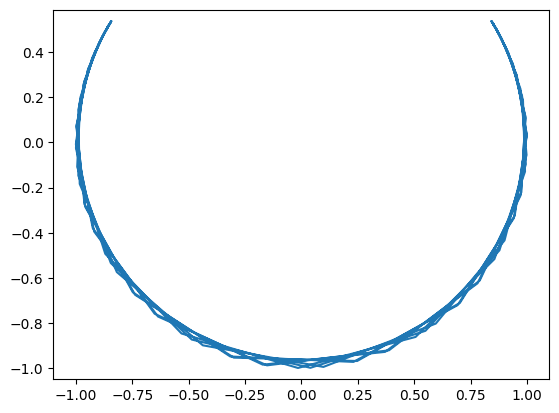

In [14]:
plt.plot(xs, ys)
plt.axis("equal");

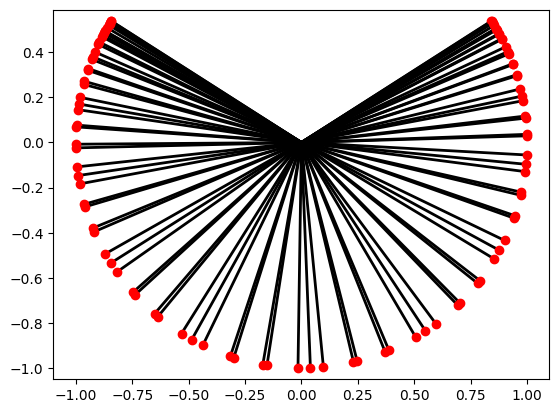

In [15]:
fig = plt.figure()
camera = Camera(fig)
for i, t in enumerate(ts):
    plt.plot([0,xs[i]],[0,ys[i]], "k-",lw=2)
    plt.plot(xs[i], ys[i], "ro")
    camera.snap()
plt.axis("equal");

In [16]:
from IPython.display import HTML
animation = camera.animate()
HTML(animation.to_jshtml())

## Péndulo elástico

Ahora usamos las coordenadas generalizadas $q_1=\theta$ y $q_2=e$, donde $e$ es el alargamiento del resorte respecto a su longitud natural $L$.

Las ecuaciones de movimiento son:

$$\begin{aligned}
\ddot{q}_1 &= -\frac{2\dot{q}_1\dot{q}_2}{L+q_2} - \frac{g\sin q_1}{L+q_2}\\
\ddot{q}_2 &= g\cos q_1 - (k/m)q_2 + (L+q_2)\dot{q}_1^2
\end{aligned}$$

y la transformación a coordenadas cartesianas en el plano es:

$$x=(L+q_2)\sin(q_1),\qquad y=-(L+q_2)\cos(q_1).$$


## Lagrangiano del péndulo elástico

Para obtener el lagrangiano, calculamos las energías cinética y potencial en términos de las coordenadas generalizadas $q_1 = \theta$ y $q_2 = e$:

### 1. Energía cinética $T$

A partir de las coordenadas cartesianas:
$$x = (L + q_2)\sin(q_1), \qquad y = -(L + q_2)\cos(q_1)$$

Las velocidades son:
$$\dot{x} = \dot{q}_2\sin(q_1) + (L+q_2)\dot{q}_1\cos(q_1)$$
$$\dot{y} = -\dot{q}_2\cos(q_1) + (L+q_2)\dot{q}_1\sin(q_1)$$

Calculando $v^2 = \dot{x}^2 + \dot{y}^2$ y simplificando:
$$v^2 = \dot{q}_2^2 + (L+q_2)^2\dot{q}_1^2$$

Por lo tanto:
$$T = \frac{1}{2}m[\dot{q}_2^2 + (L+q_2)^2\dot{q}_1^2]$$

### 2. Energía potencial $V$

- **Gravitatoria**: $V_g = mgy = -mg(L+q_2)\cos(q_1)$
- **Elástica**: $V_e = \frac{1}{2}kq_2^2$

Entonces:
$$V = -mg(L+q_2)\cos(q_1) + \frac{1}{2}kq_2^2$$

### 3. Lagrangiano $L = T - V$

$$\boxed{L = \frac{1}{2}m[\dot{q}_2^2 + (L+q_2)^2\dot{q}_1^2] + mg(L+q_2)\cos(q_1) - \frac{1}{2}kq_2^2}$$

O en términos de $\theta$ y $e$:

$$\boxed{L = \frac{1}{2}m[\dot{e}^2 + (L+e)^2\dot{\theta}^2] + mg(L+e)\cos\theta - \frac{1}{2}ke^2}$$

Este lagrangiano genera las ecuaciones de movimiento proporcionadas al aplicar las ecuaciones de Euler-Lagrange.

In [ ]:
def edm_pendulo_elastico(t, Ys, g, L, k, m):
    q1, u1, q2, u2 = Ys

    dq1_dt = u1
    dq2_dt = u2

    du1_dt = -2*u1*u2/(L + q2) - g*np.sin(q1)/(L + q2)
    du2_dt = g*np.cos(q1) - (k/m)*q2 + (L + q2)*u1**2

    return [dq1_dt, du1_dt, dq2_dt, du2_dt]

ts_e = np.linspace(0, 20, 300)
g_e = 9.8
L_e = 1.0
k_e = 35.0
m_e = 1.0
Y0_e = [30*deg, 0.0, 0.20, 0.0]

sol_e = solve_ivp(
    edm_pendulo_elastico,
    [ts_e[0], ts_e[-1]],
    Y0_e,
    args=(g_e, L_e, k_e, m_e),
    t_eval=ts_e
)

q1s = sol_e.y[0]
q2s = sol_e.y[2]
x_e = (L_e + q2s)*np.sin(q1s)
y_e = -(L_e + q2s)*np.cos(q1s)

plt.figure(figsize=(5,5))
plt.plot(x_e, y_e)
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.axis('equal')
plt.title('Trayectoria del péndulo elástico');


In [ ]:
fig = plt.figure(figsize=(5,5))
camera = Camera(fig)
for i in range(len(ts_e)):
    plt.plot([0, x_e[i]], [0, y_e[i]], 'k-', lw=2)
    plt.plot(x_e[:i+1], y_e[:i+1], 'b-', alpha=0.35)
    plt.plot(x_e[i], y_e[i], 'ro')
    plt.xlim(-1.6, 1.6)
    plt.ylim(-1.8, 0.8)
    plt.xlabel('x [m]')
    plt.ylabel('y [m]')
    plt.axis('equal')
    camera.snap()

animation_e = camera.animate(interval=70)
HTML(animation_e.to_jshtml())


## Péndulo cónico

Para el péndulo cónico usamos coordenadas generalizadas esféricas $(q_1,q_2)=(\theta,\varphi)$ con longitud fija $L$.

Las ecuaciones de movimiento (sin aproximaciones) son:

$$\begin{aligned}
\ddot{\theta} &= \sin\theta\cos\theta\,\dot{\varphi}^2 - \frac{g}{L}\sin\theta,\\
\ddot{\varphi} &= -2\,\frac{\dot{\theta}\dot{\varphi}}{\tan\theta}.
\end{aligned}$$

y las coordenadas cartesianas del movimiento son:

$$x=L\sin\theta\cos\varphi,\quad y=L\sin\theta\sin\varphi,\quad z=-L\cos\theta.$$

Cuando $\dot{\theta}=0$ y $\dot{\varphi}=\sqrt{g/(L\cos\theta)}$, se obtiene la solución cónica ideal con ángulo polar constante.


**1. Energía Cinética ($T$)**
La partícula se mueve sobre una superficie esférica de radio constante $L$. En coordenadas esféricas, la velocidad al cuadrado para un radio fijo es:
$$v^2 = (L\dot{\theta})^2 + (L\sin\theta\,\dot{\varphi})^2$$

Por lo tanto, la energía cinética es:
$$T = \frac{1}{2}m v^2 = \frac{1}{2}m L^2 (\dot{\theta}^2 + \sin^2\theta\,\dot{\varphi}^2)$$

**2. Energía Potencial ($V$)**
La coordenada vertical es $z = -L\cos\theta$. Asumiendo que la gravedad actúa hacia abajo (eje $z$ negativo) o que el potencial gravitatorio es $V = mgz$ (donde $z$ mide altura), tenemos:
$$V = mgz = mg(-L\cos\theta) = -mgL\cos\theta$$

*(Nota: El signo positivo en el Lagrangiano final confirma que el potencial es negativo respecto al origen, o que hemos definido el cero de potencial en el punto de suspensión).*

**3. Lagrangiano ($L = T - V$)**
Sustituyendo $T$ y $V$:

$$L = \left[ \frac{1}{2}m L^2 (\dot{\theta}^2 + \sin^2\theta\,\dot{\varphi}^2) \right] - \left[ -mgL\cos\theta \right]$$

**Resultado final:**

$$L = \frac{1}{2}m L^2 (\dot{\theta}^2 + \sin^2\theta\,\dot{\varphi}^2) + mgL\cos\theta$$

In [ ]:
def edm_pendulo_conico(t, Ys, g, L):
    theta, u_theta, phi, u_phi = Ys

    dtheta_dt = u_theta
    dphi_dt = u_phi

    du_theta_dt = np.sin(theta)*np.cos(theta)*u_phi**2 - (g/L)*np.sin(theta)
    if np.isclose(np.sin(theta), 0.0):
        du_phi_dt = 0.0
    else:
        du_phi_dt = -2*u_theta*u_phi/np.tan(theta)

    return [dtheta_dt, du_theta_dt, dphi_dt, du_phi_dt]

ts_c = np.linspace(0, 20, 300)
g_c = 9.8
L_c = 1.0
theta0 = 25*deg
u_theta0 = 0.0
phi0 = 0.0
u_phi0 = np.sqrt(g_c/(L_c*np.cos(theta0)))
Y0_c = [theta0, u_theta0, phi0, u_phi0]

sol_c = solve_ivp(
    edm_pendulo_conico,
    [ts_c[0], ts_c[-1]],
    Y0_c,
    args=(g_c, L_c),
    t_eval=ts_c
)

theta_c = sol_c.y[0]
phi_c = sol_c.y[2]
x_c = L_c*np.sin(theta_c)*np.cos(phi_c)
y_c = L_c*np.sin(theta_c)*np.sin(phi_c)
z_c = -L_c*np.cos(theta_c)

fig = plt.figure(figsize=(6,5))
ax = fig.add_subplot(111, projection='3d')
ax.plot(x_c, y_c, z_c)
ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
ax.set_zlabel('z [m]')
ax.set_title('Trayectoria del péndulo cónico');


In [ ]:
fig = plt.figure(figsize=(6,5))
ax = fig.add_subplot(111, projection='3d')
camera = Camera(fig)

for i in range(len(ts_c)):
    ax.plot([0, x_c[i]], [0, y_c[i]], [0, z_c[i]], 'k-', lw=2)
    ax.plot(x_c[:i+1], y_c[:i+1], z_c[:i+1], 'b-', alpha=0.35)
    ax.plot([x_c[i]], [y_c[i]], [z_c[i]], 'ro')
    ax.set_xlim(-1.0, 1.0)
    ax.set_ylim(-1.0, 1.0)
    ax.set_zlim(-1.1, 0.2)
    ax.set_xlabel('x [m]')
    ax.set_ylabel('y [m]')
    ax.set_zlabel('z [m]')
    camera.snap()

animation_c = camera.animate(interval=70)
HTML(animation_c.to_jshtml())
